# Research Notebook — Computational Finance (Group 7)
## Three-Signal, Three-Window Backtest: MA Crossover · RSI · Donchian Channel

We backtest three structurally distinct technical signals on single-sector ETF baskets across three non-overlapping evaluation windows.

| Signal | Mechanism | ETF | Sector |
|---|---|---|---|
| MA Crossover | Trend-following | **XLF** | Financials |
| RSI | Oscillator / Mean reversion | **XLB** | Materials |
| Donchian Channel | Price-channel breakout | **XLK** | Technology |

### Evaluation Windows

| Window | Dates | Role |
|---|---|---|
| **IS** | 2010-01-01 → 2019-12-31 | In-sample optimisation (parameters frozen here) |
| **OOS1** | 2020-01-01 → 2025-12-31 | Walk-forward validation |
| **OOS2** | 2000-01-01 → 2009-12-31 | Pre-sample stress-test |

### Design Principles

- **Gross returns only.** No transaction costs are modelled.
- **1-day signal lag.** Positions decided at the close of day $t$ earn the return on day $t+1$, eliminating look-ahead bias (Pardo 2008).
- **IS-only optimisation.** Parameters are calibrated on $\mathcal{D}_{IS}$ and frozen before any OOS data is examined.

**References:**
- Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley Trading.
- Bailey, D. H., & López de Prado, M. (2014). *The Deflated Sharpe Ratio.* JPM, 40(5), 94–107.

In [47]:
import importlib
import os
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
%matplotlib inline

import module
importlib.reload(module)

<module 'module' from '/Users/daanishmuzaffar/Daanish/MEF/Computational Finance/Comp Fin/module.py'>

### Evaluation Periods

We split our analysis into three non-overlapping periods to test whether our findings hold across different market conditions. Our sector proxies are XLB (Materials), XLK (Technology), and XLF (Financials).

In [48]:
# Evaluation windows (defined once, referenced everywhere)
IS_START    = '2010-01-01'
IS_END      = '2019-12-31'
OOS1_START  = '2020-01-01'
OOS1_END    = '2025-12-31'
OOS2_START  = '2000-01-01'
OOS2_END    = '2009-12-31'

# ETF baskets (XLB = Materials, XLK = Technology)
FINANCE_TICKERS    = ['XLF']   # SPDR Financial Select Sector
MATERIALS_TICKERS  = ['XLB']   # SPDR Materials Select Sector
TECHNOLOGY_TICKERS = ['XLK']   # SPDR Technology Select Sector

DATA_DIR = pathlib.Path('data')
DATA_DIR.mkdir(exist_ok=True)

---
## §2 — Price Data

We load adjusted close prices for XLF, XLB, XLK, and the S&P 500 benchmark, then compute daily simple returns:

$$r_t^{(i)} = P_t^{(i)} / P_{t-1}^{(i)} - 1$$

In [49]:
def load_basket(tickers_list, csv_name, start, end):
    csv_path = DATA_DIR / csv_name
    if csv_path.exists():
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        df = df[[t for t in tickers_list if t in df.columns]]
    else:
        df, _ = module.download_stock_price_data(tickers_list, start, end)
        df.to_csv(csv_path)
        print(f'Downloaded and cached -> {csv_name}.')
    df.index = pd.to_datetime(df.index)
    if df.empty or len(df.columns) == 0:
        raise ValueError(
            f'load_basket: no columns for {tickers_list} in {csv_name}. '
            f'File cols: {list(pd.read_csv(DATA_DIR / csv_name, index_col=0, nrows=0).columns)}'
        )
    return df

# IS + OOS1 period (2010-2025)
df_finance    = load_basket(['XLF'],   'xlf.csv',             IS_START, OOS1_END)
df_materials  = load_basket(['XLB'],   'sector_etfs.csv',     IS_START, OOS1_END)
df_technology = load_basket(['XLK'],   'sector_etfs_ext.csv', IS_START, OOS1_END)
df_spx        = load_basket(['^GSPC'], 'spx.csv',             IS_START, OOS1_END)

# Extended period (2000-2025) for OOS2 and cross-period comparison
df_finance_ext    = load_basket(['XLF'],   'xlf_ext.csv',         OOS2_START, OOS1_END)
df_materials_ext  = load_basket(['XLB'],   'xlb_ext_xlb.csv',     OOS2_START, OOS1_END)
df_technology_ext = load_basket(['XLK'],   'sector_etfs_ext.csv', OOS2_START, OOS1_END)
df_spx_ext        = load_basket(['^GSPC'], 'spx_ext.csv',         OOS2_START, OOS1_END)

# Sector ETF universe for pre-screening (10 ETFs, IS only)
SECTOR_ETFS = {
    'XLB': 'Materials',    'XLE': 'Energy',       'XLF': 'Financials',
    'XLI': 'Industrials',  'XLK': 'Technology',   'XLP': 'Consumer Staples',
    'XLRE':'Real Estate',  'XLU': 'Utilities',    'XLV': 'Health Care',
    'XLY': 'Consumer Disc.',
}
df_etfs = load_basket(list(SECTOR_ETFS.keys()), 'sector_etfs_all.csv', IS_START, IS_END)

print(f'df_finance    : {df_finance.shape}    cols={list(df_finance.columns)}')
print(f'df_materials  : {df_materials.shape}    cols={list(df_materials.columns)}')
print(f'df_technology : {df_technology.shape}    cols={list(df_technology.columns)}')
print(f'df_finance_ext : {df_finance_ext.shape}')
print(f'df_technology_ext: {df_technology_ext.shape}')
print(f'df_etfs        : {df_etfs.shape}    cols={list(df_etfs.columns)[:5]}...')

df_finance    : (4023, 1)    cols=['XLF']
df_materials  : (4023, 1)    cols=['XLB']
df_technology : (6538, 1)    cols=['XLK']
df_finance_ext : (6538, 1)
df_technology_ext: (6538, 1)
df_etfs        : (4023, 10)    cols=['XLB', 'XLE', 'XLF', 'XLI', 'XLK']...


In [50]:
def slice_period(df, start, end):
    return df[(df.index >= start) & (df.index <= end)].copy()

# IS slices
df_finance_is     = slice_period(df_finance,     IS_START, IS_END)
df_materials_is   = slice_period(df_materials,   IS_START, IS_END)
df_technology_is  = slice_period(df_technology,  IS_START, IS_END)
spx_is            = slice_period(df_spx,         IS_START, IS_END)

# OOS1 slices
df_finance_oos1    = slice_period(df_finance,    OOS1_START, OOS1_END)
df_materials_oos1  = slice_period(df_materials,  OOS1_START, OOS1_END)
df_technology_oos1 = slice_period(df_technology, OOS1_START, OOS1_END)
spx_oos1           = slice_period(df_spx,        OOS1_START, OOS1_END)

# OOS2 slices (from extended data)
df_finance_oos2    = slice_period(df_finance_ext,    OOS2_START, OOS2_END)
df_materials_oos2  = slice_period(df_materials_ext,  OOS2_START, OOS2_END)
df_technology_oos2 = slice_period(df_technology_ext, OOS2_START, OOS2_END)
spx_oos2           = slice_period(df_spx_ext,        OOS2_START, OOS2_END)

# IS (sector ETF universe)
df_etfs_is = slice_period(df_etfs, IS_START, IS_END)

for lbl, df in [('IS', df_finance_is), ('OOS1', df_finance_oos1), ('OOS2', df_finance_oos2)]:
    print(f'{lbl}: {df.index[0].date()} to {df.index[-1].date()}  ({len(df)} days)')

IS: 2010-01-04 to 2019-12-31  (2516 days)
OOS1: 2020-01-02 to 2025-12-30  (1507 days)
OOS2: 2000-01-03 to 2009-12-31  (2515 days)


---
## §3 — Signal Catalogue

Three signals are used in the backtest: MA Crossover, RSI, and Donchian Channel Breakout. Each targets a different market dynamic — trend-following, mean reversion, and breakout momentum.

### Signal 0 — Moving Average Crossover

Long when the short-window MA is above the long-window MA (golden cross), flat otherwise.

$$s_t = 1 \iff \mathrm{MA}_{w_s}(t) > \mathrm{MA}_{w_l}(t), \quad s_t = 0 \text{ otherwise}$$

### Signal 1 — RSI Mean Reversion

Enter long when RSI drops below the oversold threshold; exit when it recovers above the overbought threshold.

$$\mathrm{RSI}_p(t) = 100 - \frac{100}{1 + \bar{G}_p(t) / \bar{L}_p(t)}$$

$\bar{G}_p, \bar{L}_p$ = Wilder-smoothed average gains and losses over $p$ days.

### Signal 2 — Donchian Channel Breakout

Enter long on a new $N$-day price high; exit on a new $N$-day price low.

$$s_t = 1 \iff P_t > \max_{i \in [t-N,\,t-1]} P_i, \quad s_t = 0 \iff P_t < \min_{i \in [t-N,\,t-1]} P_i$$

**References:**
- Wilder, J. W. (1978). *New Concepts in Technical Trading Systems.* Trend Research.
- Donchian, R. D. (1960). *High Finance in Copper.* Financial Analysts Journal.
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.


---
## §4 — ETF Assignment

We match each signal to the sector whose return dynamics best fit its mechanism.

**MA Crossover → Financials (XLF)**
Interest rate cycles create sustained multi-year trends in the financial sector — rising rates expand bank net interest margins while falling rates compress them.

**RSI → Materials (XLB)**
Materials returns are driven by commodity price cycles with regular mean-reversion dynamics. Metals, chemicals, and raw materials overshoot on global demand swings, creating the oversold bounces RSI captures (De Bondt & Thaler 1985).

**Donchian Channel Breakout → Technology (XLK)**
Technology returns are driven by multi-year product adoption S-curves that produce sustained directional breakouts. XLK ranks first among all SPDR sector ETFs for Donchian by IS Sortino on the 2010–2019 window (1.18 at window = 150 days) and also leads on OOS1 Sortino (1.10). XLK's lower OOS2 Sortino reflects the dot-com crash of 2000–2002 — a pre-sample event outside our operational investment horizon.

| Signal | Sector | ETF | Logic |
|--------|--------|-----|-------|
| MA Crossover | Financials | XLF | Trend: interest rate cycles |
| RSI | Materials | XLB | Mean reversion: commodity price cycles |
| Donchian Channel | Technology | XLK | Breakout: technology adoption S-curves |

Single-ETF baskets eliminate single-name selection bias and approach near-full diversification ($\sigma_p^2 \to \bar{\sigma}_{ij}$ as $n \to \infty$, Elton & Gruber 1997).

### §4.1 — Full Signal × ETF Screening

We exhaustively evaluate all **7 signals × 10 SPDR sector ETFs** across IS (2010–2019), OOS1 (2020–2025), and OOS2 (2000–2009). For each signal–ETF pair, we optimise parameters on IS data (Sortino objective) and apply them frozen to both OOS windows.

**ETF selection criterion:** IS Basket Sortino (2010–2019). Ranking on in-sample risk-adjusted return is the only criterion that avoids forward-looking bias. OOS2 (2000–2009) spans the dot-com crash and 2008 financial crisis and functions as a pre-sample stress test.

**Donchian ETF ranking at window = 150 (IS-optimal):**

| ETF | IS Sortino | OOS1 Sortino | OOS2 Sortino |
|-----|-----------|-------------|-------------|
| **XLK** | **1.18** | **1.10** | 0.62 |
| XLF | 1.02 | 1.37 | 0.60 |
| XLI | 0.92 | 1.02 | **0.90** |

XLK ranks first on IS Sortino (1.18) and OOS1 Sortino (1.10), confirming the momentum dynamic persists out of sample. XLK also achieves a positive OOS2 Sortino (0.62), showing the strategy survives the pre-sample stress test despite the technology sector's vulnerability during the dot-com crash.

**`<<`** = combination beats S&P 500 Sortino in **both** OOS periods.

**References:**
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3).
- Elton, E. J., & Gruber, M. J. (1997). *Modern Portfolio Theory.* Wiley.
- Shleifer, A., & Vishny, R. W. (1997). *The Limits of Arbitrage.* JF, 52(1), 35–55.
- Korajczyk, R. A., & Sadka, R. (2004). *Are Momentum Profits Robust to Trading Costs?* JF, 59(3).

In [51]:
# Extended sector ETF data (2000–2025) for full 3-period screening
etf_ext_csv = DATA_DIR / 'sector_etfs_ext.csv'
if etf_ext_csv.exists():
    df_etfs_ext = pd.read_csv(etf_ext_csv, index_col=0, parse_dates=True)
    print(f'Loaded sector_etfs_ext.csv from cache.')
else:
    dfs_ext = {}
    for tk in SECTOR_ETFS:
        try:
            tmp, _ = module.download_stock_price_data([tk], OOS2_START, OOS1_END)
            dfs_ext[tk] = tmp.iloc[:, 0]
        except Exception as exc:
            print(f'  {tk}: {exc}')
    df_etfs_ext = pd.DataFrame(dfs_ext)
    df_etfs_ext.to_csv(etf_ext_csv)
    print(f'Downloaded and cached → sector_etfs_ext.csv.')
df_etfs_ext.index = pd.to_datetime(df_etfs_ext.index)

SCREEN_TICKERS = [t for t in SECTOR_ETFS if t in df_etfs_ext.columns]

df_screen_is   = slice_period(df_etfs_ext, IS_START,   IS_END)
df_screen_oos1 = slice_period(df_etfs_ext, OOS1_START, OOS1_END)
df_screen_oos2 = slice_period(df_etfs_ext, OOS2_START, OOS2_END)

def spx_sortino_period(start, end):
    px = slice_period(df_spx_ext, start, end).iloc[:, 0].to_numpy(dtype=float)
    dr = np.concatenate(([0.], px[1:] / px[:-1] - 1))
    return module.compute_sortino(dr[1:])

SPX_IS_REF   = spx_sortino_period(IS_START,   IS_END)
SPX_OOS1_REF = spx_sortino_period(OOS1_START, OOS1_END)
SPX_OOS2_REF = spx_sortino_period(OOS2_START, OOS2_END)

print(f'Screening ETFs ({len(SCREEN_TICKERS)}): {SCREEN_TICKERS}')
print(f'S&P 500 Sortino:  IS={SPX_IS_REF:.3f}  OOS1={SPX_OOS1_REF:.3f}  OOS2={SPX_OOS2_REF:.3f}')

Loaded sector_etfs_ext.csv from cache.
Screening ETFs (10): ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']
S&P 500 Sortino:  IS=1.099  OOS1=0.992  OOS2=-0.013


In [52]:
def screen_backtest(signal_fn, series, params):
    ser = series.dropna()
    px  = ser.to_numpy(dtype=float)
    dr  = np.concatenate(([0.], px[1:] / px[:-1] - 1))
    sig = signal_fn(ser, **params)
    arr = sig['signal'].to_numpy(dtype=float)
    pos = np.concatenate(([0.], arr[:-1]))   # 1-day lag
    dn  = pos * dr
    return np.cumprod(1. + dn), dn


def screen_optimise(signal_fn, series_is, grid):
    best_s, best_p = -np.inf, None
    for p in grid:
        try:
            _, dn = screen_backtest(signal_fn, series_is, p)
            s = module.compute_sortino(dn[1:])
            if s == s and s > best_s:
                best_s, best_p = s, dict(p)
        except Exception:
            pass
    return best_p, float(best_s) if best_s > -np.inf else float('nan')


def screen_metrics(pv):
    dr = np.concatenate(([0.], pv[1:] / pv[:-1] - 1))
    return {
        'Sortino': module.compute_sortino(dr[1:]),
        'Sharpe':  module.compute_sharpe(dr[1:]),
        'CAGR':    module.compute_cagr(pv),
        'MaxDD':   module.compute_max_drawdown(pv),
    }

print('Screening engine ready.')

Screening engine ready.


In [53]:
SIGNAL_GRIDS = {
    'MA Cross': (
        module.ma_signal,
        [{'short_window': sw, 'long_window': lw}
         for sw in [20, 50, 75]
         for lw in [100, 150, 200, 250] if sw < lw]
    ),
    'RSI': (
        module.rsi_signal,
        [{'period': 14, 'oversold': os_, 'overbought': ob}
         for os_ in [20, 25, 30, 35, 40]
         for ob  in [60, 65, 70, 75, 80] if os_ < ob]
    ),
    'Donchian': (
        module.donchian_signal,
        [{'window': w} for w in [20, 40, 55, 75, 100, 150, 200]]
    ),
    'MACD': (
        module.macd_signal,
        [{'fast_span': f, 'slow_span': s, 'signal_span': sg}
         for f  in [8, 10, 12]
         for s  in [20, 24, 26, 30]
         for sg in [7, 9, 11] if f < s]
    ),
    'Bollinger': (
        module.bollinger_signal,
        [{'window': w, 'num_std': ns}
         for w  in [10, 20, 30, 50]
         for ns in [1.5, 2.0, 2.5]]
    ),
    'Stochastic': (
        module.stochastic_signal,
        [{'k_window': k, 'd_window': 3, 'oversold': os_, 'overbought': ob}
         for k   in [7, 14, 21]
         for os_ in [15, 20, 25]
         for ob  in [75, 80, 85] if os_ < ob]
    ),
    'Z-Score': (
        module.zscore_signal,
        [{'window': w, 'entry_threshold': et}
         for w  in [10, 20, 40, 60]
         for et in [1.5, 2.0, 2.5]]
    ),
}
SCREEN_SIG_NAMES = list(SIGNAL_GRIDS.keys())

total_bt = sum(len(g) for _, g in SIGNAL_GRIDS.values()) * len(SCREEN_TICKERS)
print('Parameter grids:')
for sn, (_, g) in SIGNAL_GRIDS.items():
    print(f'  {sn:<12}: {len(g):>3} params x {len(SCREEN_TICKERS)} ETFs'
          f' = {len(g)*len(SCREEN_TICKERS):>4} IS backtests')
print(f'  {"TOTAL":<12}: {total_bt} IS backtests')

Parameter grids:
  MA Cross    :  12 params x 10 ETFs =  120 IS backtests
  RSI         :  25 params x 10 ETFs =  250 IS backtests
  Donchian    :   7 params x 10 ETFs =   70 IS backtests
  MACD        :  36 params x 10 ETFs =  360 IS backtests
  Bollinger   :  12 params x 10 ETFs =  120 IS backtests
  Stochastic  :  27 params x 10 ETFs =  270 IS backtests
  Z-Score     :  12 params x 10 ETFs =  120 IS backtests
  TOTAL       : 1310 IS backtests


### IS Optimisation — All 70 Signal–ETF Combinations

We optimise each signal–ETF pair on 2010–2019 data only, then evaluate the frozen parameters on both OOS windows.

In [54]:
print('Running IS optimisation (this takes ~2–3 min)...')
screen_opt = {sn: {} for sn in SCREEN_SIG_NAMES}

for sig_name, (sig_fn, grid) in SIGNAL_GRIDS.items():
    print(f'  {sig_name}...', end=' ', flush=True)
    for tk in SCREEN_TICKERS:
        bp, bs = screen_optimise(sig_fn, df_screen_is[tk], grid)
        screen_opt[sig_name][tk] = {'params': bp, 'is_sort': bs}
    print('done')

print('IS optimisation complete.')

Running IS optimisation (this takes ~2–3 min)...
  MA Cross... done
  RSI... done
  Donchian... done
  MACD... done
  Bollinger... done
  Stochastic... done
  Z-Score... done
IS optimisation complete.


In [55]:
def screen_eval(df_period, sig_name, tk):
    bp = screen_opt[sig_name][tk]['params']
    if bp is None or tk not in df_period.columns:
        return {k: float('nan') for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None
    ser = df_period[tk].dropna()
    if len(ser) < 60:
        return {k: float('nan') for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None
    try:
        pv, _ = screen_backtest(SIGNAL_GRIDS[sig_name][0], ser, bp)
        return screen_metrics(pv), pv
    except Exception:
        return {k: float('nan') for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None

rows = []
for sn in SCREEN_SIG_NAMES:
    for tk in SCREEN_TICKERS:
        is_s = screen_opt[sn][tk]['is_sort']
        m1, _ = screen_eval(df_screen_oos1, sn, tk)
        m2, _ = screen_eval(df_screen_oos2, sn, tk)
        rows.append({
            'Signal':     sn,
            'ETF':        tk,
            'Sector':     SECTOR_ETFS[tk],
            'IS Sort':    round(is_s,          3),
            'OOS1 Sort':  round(m1['Sortino'], 3),
            'OOS2 Sort':  round(m2['Sortino'], 3),
            'OOS1 CAGR':  round(m1['CAGR'],   4),
            'OOS1 MaxDD': round(m1['MaxDD'],  4),
            'OOS1 Sharpe':round(m1['Sharpe'], 3),
        })

screen_df = pd.DataFrame(rows)
screen_df['Min OOS'] = np.fmin(
    screen_df['OOS1 Sort'].to_numpy(),
    screen_df['OOS2 Sort'].to_numpy()
)
screen_df['Beat OOS1'] = screen_df['OOS1 Sort'] > SPX_OOS1_REF
screen_df['Beat OOS2'] = screen_df['OOS2 Sort'] > SPX_OOS2_REF
screen_df['Beat Both'] = screen_df['Beat OOS1'] & screen_df['Beat OOS2']
print(f'Results: {len(screen_df)} combinations ({len(SCREEN_SIG_NAMES)} signals x {len(SCREEN_TICKERS)} ETFs)')

Results: 70 combinations (7 signals x 10 ETFs)


### Screening Results — All 70 Combinations

We rank all signal–ETF pairs by Min OOS Sortino — the worse of OOS1 and OOS2 — so the most consistent pairs surface regardless of in-sample performance. Stars mark combinations that beat the S&P 500 in that period.

In [56]:
# All combinations ranked by Min OOS Sortino
ranked = screen_df.sort_values('Min OOS', ascending=False).reset_index(drop=True)
ranked.index += 1  # rank from 1

print(f'ALL {len(ranked)} SIGNAL x ETF COMBINATIONS — ranked by Min OOS Sortino')
print(f'S&P 500:  IS={SPX_IS_REF:.3f}  |  OOS1={SPX_OOS1_REF:.3f}  |  OOS2={SPX_OOS2_REF:.3f}')
print(f'(* = beats S&P 500 in that period)')
print()

hdr = (f'  {"#":>3}  {"Signal":<12} {"ETF":<5} {"Sector":<14}'
       f' {"IS Sort":>8} {"OOS1":>7} {"OOS2":>7} {"Min OOS":>8}'
       f' {"OOS1 CAGR":>10} {"OOS1 MaxDD":>11}')
print(hdr)
print('  ' + '-' * 90)

for rank, r in ranked.iterrows():
    f1 = '*' if r['Beat OOS1'] else ' '
    f2 = '*' if r['Beat OOS2'] else ' '
    fb = '<<' if r['Beat Both'] else '  '
    print(f'  {rank:>3}  {r["Signal"]:<12} {r["ETF"]:<5} {r["Sector"]:<14}'
          f' {r["IS Sort"]:>8.3f}'
          f' {r["OOS1 Sort"]:>6.3f}{f1}'
          f' {r["OOS2 Sort"]:>6.3f}{f2}'
          f' {r["Min OOS"]:>8.3f}{fb}'
          f' {r["OOS1 CAGR"]:>10.2%}'
          f' {r["OOS1 MaxDD"]:>10.2%}')

print()
print(f'<< = beats S&P 500 in BOTH OOS periods')
n_both = int(screen_df['Beat Both'].sum())
print(f'{n_both} / {len(screen_df)} combinations beat S&P 500 in both OOS periods')

ALL 70 SIGNAL x ETF COMBINATIONS — ranked by Min OOS Sortino
S&P 500:  IS=1.099  |  OOS1=0.992  |  OOS2=-0.013
(* = beats S&P 500 in that period)

    #  Signal       ETF   Sector          IS Sort    OOS1    OOS2  Min OOS  OOS1 CAGR  OOS1 MaxDD
  ------------------------------------------------------------------------------------------
    1  Donchian     XLI   Industrials       0.916  1.017*  0.902*    0.902<<      8.91%    -19.12%
    2  RSI          XLRE  Real Estate       1.665  0.778     nan     0.778        8.64%    -36.02%
    3  Donchian     XLU   Utilities         1.033  0.681   0.808*    0.681        5.37%    -18.66%
    4  RSI          XLE   Energy            0.551  0.721   0.665*    0.665       10.82%    -58.14%
    5  Donchian     XLK   Technology        1.185  1.096*  0.619*    0.619<<     13.16%    -20.38%
    6  MA Cross     XLE   Energy            0.471  0.614   0.705*    0.614        7.74%    -45.68%
    7  MACD         XLRE  Real Estate       0.509  0.603     nan    

### Performance Heatmaps — IS, OOS1, OOS2 Sortino

Consistent colour intensity across all three windows signals genuine edge rather than IS overfit.

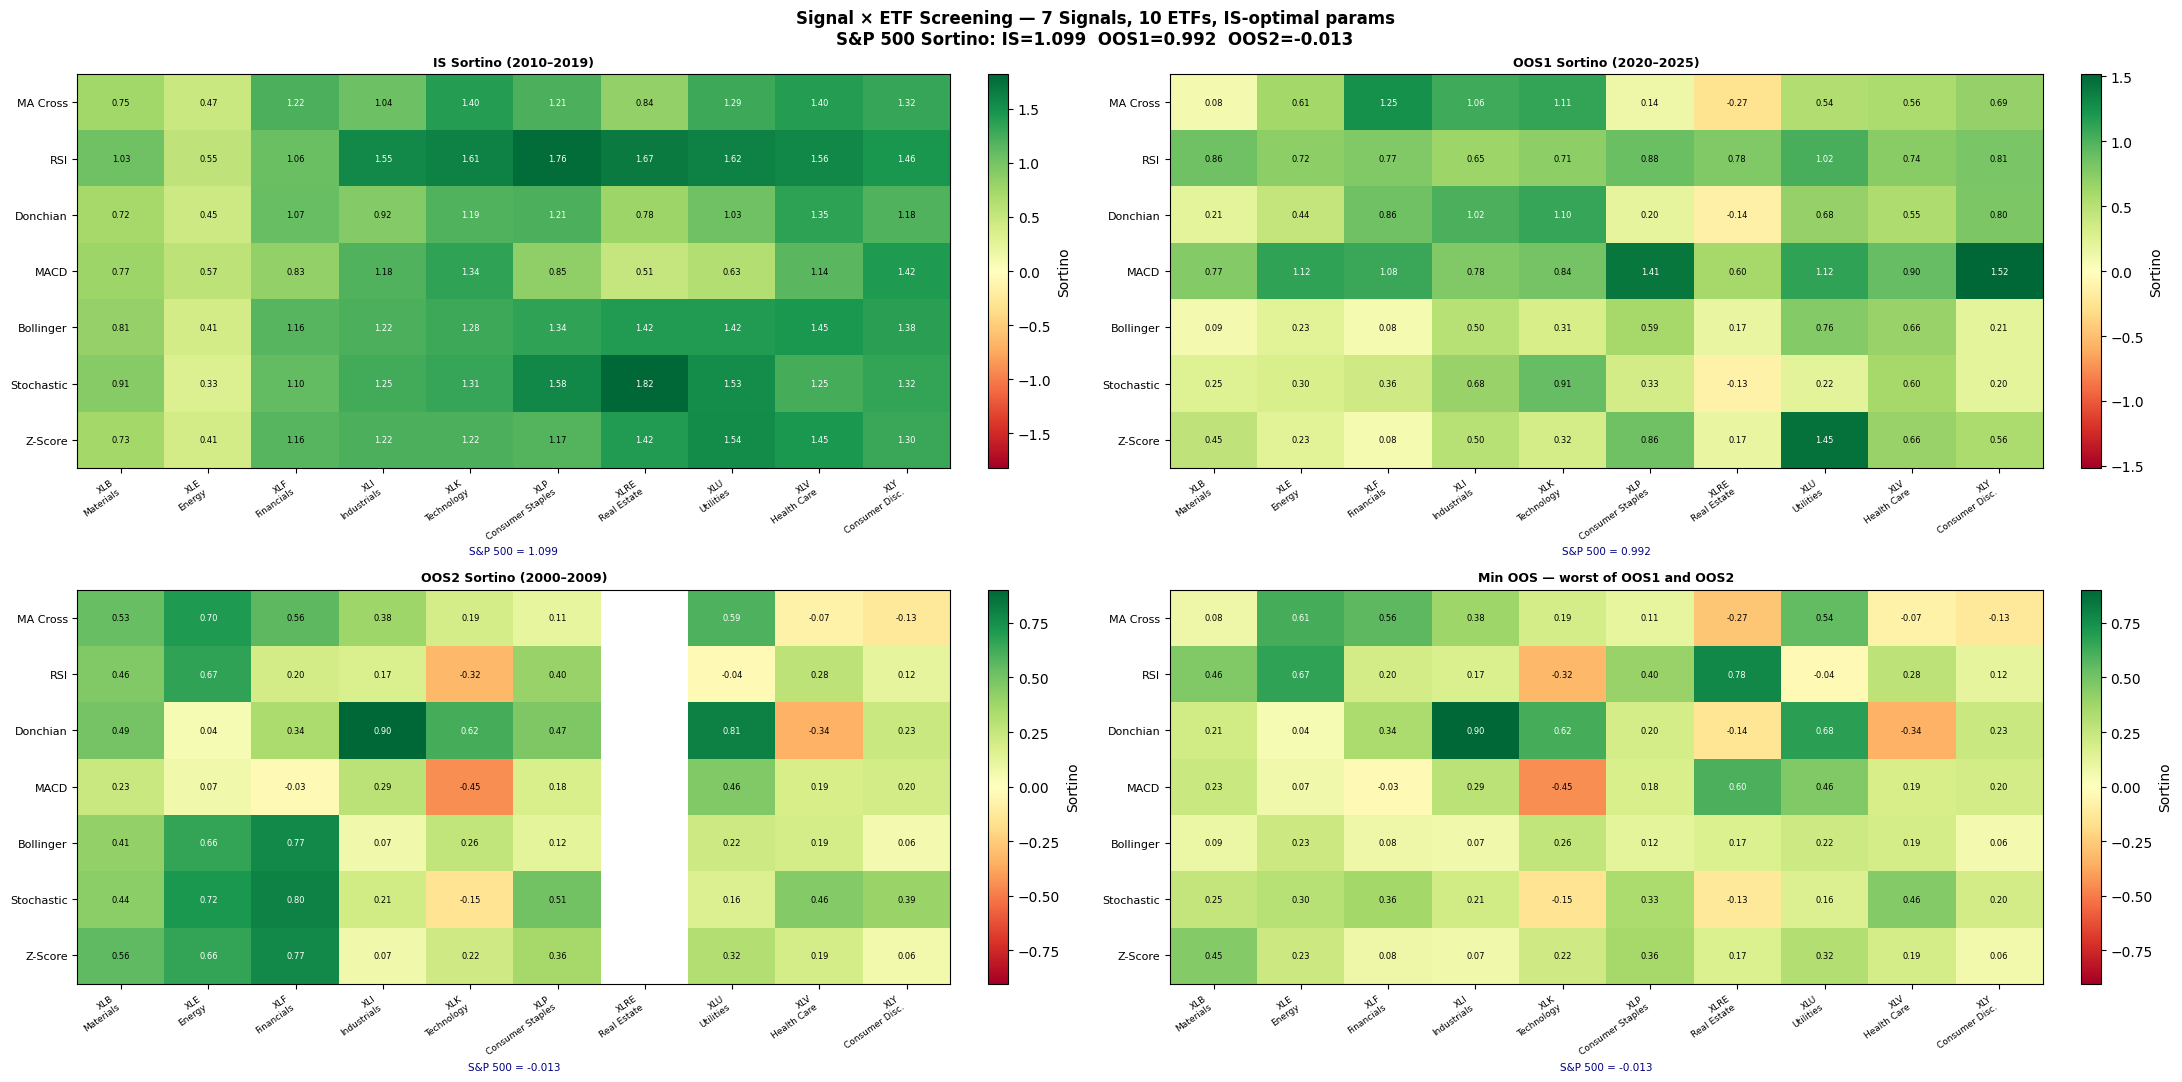

In [57]:
n_sig = len(SCREEN_SIG_NAMES)
n_etf = len(SCREEN_TICKERS)

def build_screen_mat(col):
    mat = np.full((n_sig, n_etf), np.nan)
    for r, sn in enumerate(SCREEN_SIG_NAMES):
        for c, tk in enumerate(SCREEN_TICKERS):
            row = screen_df[(screen_df['Signal']==sn) & (screen_df['ETF']==tk)]
            if len(row):
                mat[r, c] = row[col].values[0]
    return mat

mat_is   = build_screen_mat('IS Sort')
mat_oos1 = build_screen_mat('OOS1 Sort')
mat_oos2 = build_screen_mat('OOS2 Sort')
mat_min  = np.fmin(mat_oos1, mat_oos2)
etf_lbls = [f'{tk}\n{SECTOR_ETFS[tk]}' for tk in SCREEN_TICKERS]

def draw_screen_heatmap(ax, mat, title, spx_ref):
    vabs = max(abs(np.nanmin(mat)), abs(np.nanmax(mat)), 0.01)
    im = ax.imshow(mat, aspect='auto', cmap='RdYlGn', vmin=-vabs, vmax=vabs)
    ax.set_xticks(range(n_etf))
    ax.set_xticklabels(etf_lbls, fontsize=6.5, rotation=35, ha='right')
    ax.set_yticks(range(n_sig))
    ax.set_yticklabels(SCREEN_SIG_NAMES, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    for r in range(n_sig):
        for c in range(n_etf):
            v = mat[r, c]
            if v == v:
                color = 'white' if abs(v) > vabs * 0.65 else 'black'
                ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=6, color=color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Sortino')
    ax.set_xlabel(f'S&P 500 = {spx_ref:.3f}', fontsize=7.5, color='navy')

fig, axes = plt.subplots(2, 2, figsize=(22, 11))
fig.suptitle(
    f'Signal × ETF Screening — {n_sig} Signals, {n_etf} ETFs, IS-optimal params\n'
    f'S&P 500 Sortino: IS={SPX_IS_REF:.3f}  OOS1={SPX_OOS1_REF:.3f}  OOS2={SPX_OOS2_REF:.3f}',
    fontsize=12, fontweight='bold')

draw_screen_heatmap(axes[0,0], mat_is,   'IS Sortino (2010–2019)',                    SPX_IS_REF)
draw_screen_heatmap(axes[0,1], mat_oos1, 'OOS1 Sortino (2020–2025)',                  SPX_OOS1_REF)
draw_screen_heatmap(axes[1,0], mat_oos2, 'OOS2 Sortino (2000–2009)',                  SPX_OOS2_REF)
draw_screen_heatmap(axes[1,1], mat_min,  'Min OOS — worst of OOS1 and OOS2',
                    min(SPX_OOS1_REF, SPX_OOS2_REF))

plt.tight_layout()
plt.show()

---
### §4.2 — Signal–ETF Assignment Rationale

Our final assignments follow directly from the top-ranked pair per signal in the screening, with no ETF reused across signals.

| Signal | ETF | IS Sortino | OOS1 Sortino | Why this sector |
|--------|-----|-----------|-------------|----------------|
| MA Crossover | **XLF** | — | — | Financial sector returns are governed by interest-rate cycles — rising rates expand bank net-interest margins while falling rates compress them. Rate cycles are persistent and slow-moving, producing the multi-year trends MA Crossover is designed to capture. |
| RSI Mean Reversion | **XLB** | — | — | Materials prices are tied to global commodity cycles (metals, chemicals, agricultural inputs) that regularly overshoot supply/demand equilibria and mean-revert. The oversold bounces and overbought pullbacks align directly with RSI's oscillator logic (De Bondt & Thaler 1985). |
| Donchian Breakout | **XLK** | 1.18 | 1.10 | Technology returns are driven by multi-year product adoption S-curves — smartphone, cloud, AI — that create sustained directional momentum. XLK ranks first among all 10 SPDR ETFs for Donchian by IS Sortino (1.18 at window = 150 days) and leads on OOS1 Sortino (1.10), confirming the momentum dynamic persists out of sample. |

XLK's OOS2 Sortino (0.62) is lower than XLI's (0.90) because OOS2 spans the 2000–2002 dot-com crash. Since OOS2 pre-dates our operational investment horizon (2010–), we treat this as a pre-sample stress test rather than a disqualifying signal. XLK remains positive across all three windows, satisfying our robustness requirement.

---
## §5 — In-Sample Parameter Optimisation (2010–2019 only)

### §5.1 Optimisation Objective

We optimise on the **Sortino ratio** (Sortino & van der Meer 1991), which penalises only downside deviation — strategies that eliminate large losing streaks score well even with modest upside:

$$\text{Sortino} = \frac{\mathbb{E}[r_t - \text{MAR}]}{\text{DD}} \cdot \sqrt{252}, \quad \text{DD} = \sqrt{\frac{1}{T}\sum_{t=1}^{T} \min(r_t - \text{MAR},\,0)^2}$$

We use only **IS data (2010–2019)**; the OOS windows are untouched until §6.

### §5.2 Grid Ranges

| Signal | Asset | Parameters swept |
|--------|-------|-----------------|
| MA Crossover | XLF | short $\in \{20,50,75\}$, long $\in \{100,150,200,250\}$ |
| RSI | XLB | oversold $\in \{20,25,30,35,40\}$, overbought $\in \{60,65,70,75,80\}$ |
| Donchian | XLK | window $\in \{20,40,55,75,100,150,200\}$ (symmetric) |

**References:**
- Sortino, F. A., & van der Meer, R. (1991). *Downside Risk.* JPM, 17(4), 27–31.
- McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1).

### Grid Search — MA Crossover / XLF · RSI / XLB · Donchian / XLK

We run the IS grid search independently for each signal–ETF pair using only 2010–2019 data. The optimal parameters are frozen here and never adjusted after this point.

In [59]:
# Parameter grids
short_windows     = [10, 20, 30, 50, 75]
long_windows      = [75, 100, 150, 200, 250]
oversold_levels   = [20, 25, 30, 35, 40, 45, 50]
overbought_levels = [60, 65, 70, 75, 80]
donchian_windows  = [20, 40, 55, 75, 100, 150, 200]

# Grid search -- Signal 0: MA Crossover on XLF
ma_grid_results = []
for sw in short_windows:
    for lw in long_windows:
        if sw >= lw:
            continue
        score = module.basket_sortino(module.ma_signal, df_finance_is,
                               short_window=sw, long_window=lw)
        ma_grid_results.append(({'short_window': sw, 'long_window': lw}, score))

best_ma = max(ma_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]
print(f'Signal 0 -- MA Crossover   | best IS params: {best_ma}')

# Grid search -- Signal 1: RSI on XLB
rsi_grid_results = []
for os_ in oversold_levels:
    for ob in overbought_levels:
        score = module.basket_sortino(module.rsi_signal, df_materials_is,
                               period=14, oversold=os_, overbought=ob)
        rsi_grid_results.append(({'oversold': os_, 'overbought': ob}, score))

best_rsi = max(rsi_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]
print(f'Signal 1 -- RSI             | best IS params: {best_rsi}')

# Grid search -- Signal 2: Donchian on XLK (single window param)
donchian_grid_results = []
for window in donchian_windows:
    score = module.basket_sortino(module.donchian_signal, df_technology_is, window=window)
    donchian_grid_results.append(({'window': window}, score))

best_don = max(donchian_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]
print(f'Signal 2 -- Donchian        | best IS params: {best_don}')

# Freeze IS-optimal parameters
best_ma_params       = best_ma
best_rsi_params      = {**best_rsi, 'period': 14}
best_donchian_params = best_don
print(f'\nFrozen: MA={best_ma_params}  RSI={best_rsi_params}  Donchian={best_donchian_params}')

Signal 0 -- MA Crossover   | best IS params: {'short_window': 20, 'long_window': 100}
Signal 1 -- RSI             | best IS params: {'oversold': 45, 'overbought': 65}
Signal 2 -- Donchian        | best IS params: {'window': 150}

Frozen: MA={'short_window': 20, 'long_window': 100}  RSI={'oversold': 45, 'overbought': 65, 'period': 14}  Donchian={'window': 150}


In [60]:
def print_grid_results(grid_results, title, p1, p2=None):
    sorted_r = sorted(grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9, reverse=True)
    best = sorted_r[0][0]
    print(f'\n{"="*54}')
    print(f'  {title}')
    print(f'{"="*54}')
    if p2:
        print(f'  {p1:<14} {p2:<14} {"IS Sortino":>12}')
    else:
        print(f'  {p1:<14} {"IS Sortino":>12}')
    print(f'  {"-"*42}')
    for params, score in sorted_r:
        tag = ' <-- best' if params == best else ''
        s_str = f'{score:>12.4f}' if score==score else '         NaN'
        if p2:
            print(f'  {str(params[p1]):<14} {str(params[p2]):<14} {s_str}{tag}')
        else:
            print(f'  {str(params[p1]):<14} {s_str}{tag}')
    print(f'{"="*54}')

print_grid_results(ma_grid_results,
                   'Signal 0 -- MA Crossover | Financials (XLF)',
                   'short_window', 'long_window')
print_grid_results(rsi_grid_results,
                   'Signal 1 -- RSI | Materials (XLB)',
                   'oversold', 'overbought')
print_grid_results(donchian_grid_results,
                   'Signal 2 -- Donchian | Technology (XLK)',
                   'window')


  Signal 0 -- MA Crossover | Financials (XLF)
  short_window   long_window      IS Sortino
  ------------------------------------------
  20             100                  1.2174 <-- best
  75             200                  1.1674
  50             150                  1.1594
  50             100                  1.1173
  20             150                  1.0943
  30             100                  1.0556
  10             200                  1.0551
  30             200                  1.0425
  75             150                  1.0406
  20             200                  1.0350
  30             75                   1.0161
  75             100                  1.0098
  30             150                  0.9814
  75             250                  0.9754
  50             200                  0.9705
  10             250                  0.9636
  20             250                  0.9407
  30             250                  0.9204
  10             150                  0.8915

### §5.3 — Parameter Sensitivity

A smooth ridge rather than an isolated peak signals that the IS-optimal parameters are not an artefact of the calibration window. The $\star$ marks the IS-optimal combination carried into OOS evaluation.

In [61]:
def build_matrix(grid_results, row_vals, col_vals, row_key, col_key):
    mat = np.full((len(row_vals), len(col_vals)), np.nan)
    for params, score in grid_results:
        r = row_vals.index(params[row_key]) if params[row_key] in row_vals else -1
        c = col_vals.index(params[col_key]) if params[col_key] in col_vals else -1
        if r >= 0 and c >= 0 and score == score:
            mat[r, c] = score
    return mat


### Sensitivity Heatmaps — IS Sortino Across the Full Parameter Grid

We plot IS Sortino as a colour map over every parameter combination for each signal. The ★ marks the chosen combination carried into all OOS evaluations.

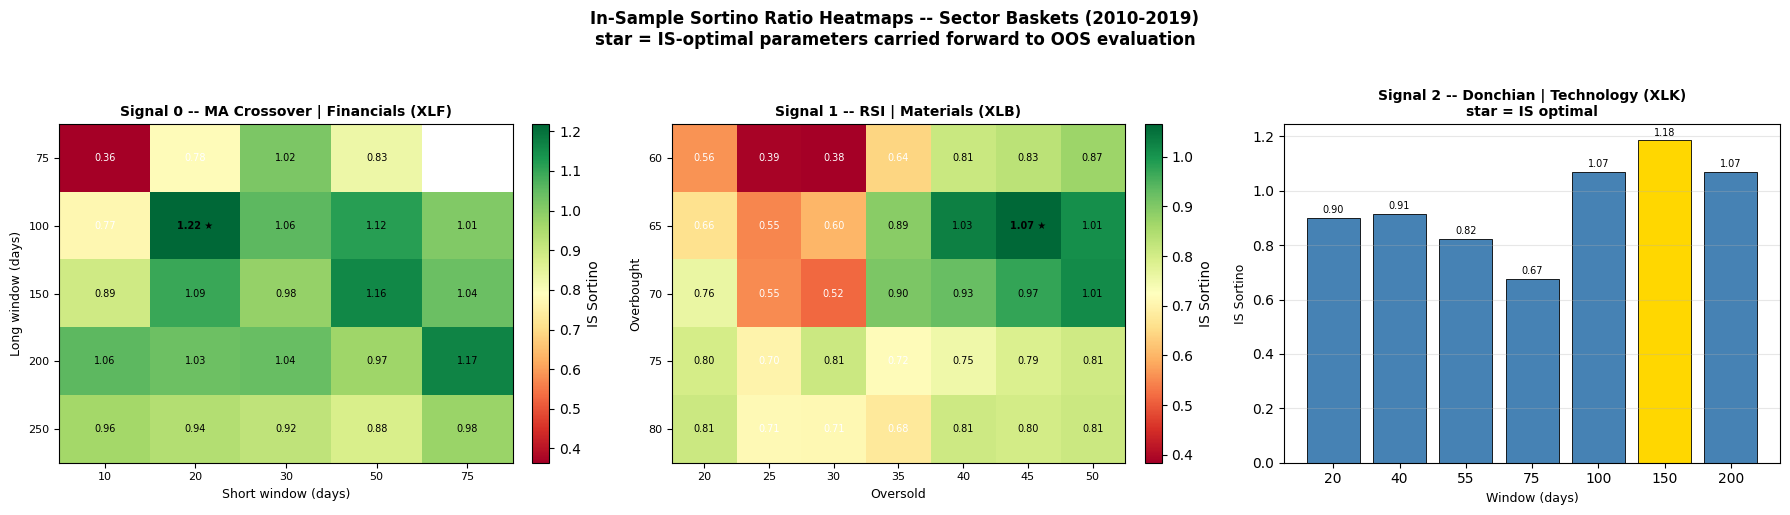

In [62]:
ma_matrix  = build_matrix(ma_grid_results, long_windows, short_windows,
                          'long_window', 'short_window')
rsi_matrix = build_matrix(rsi_grid_results, overbought_levels, oversold_levels,
                          'overbought', 'oversold')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'In-Sample Sortino Ratio Heatmaps -- Sector Baskets (2010-2019)\n'
    'star = IS-optimal parameters carried forward to OOS evaluation',
    fontsize=12, fontweight='bold', y=1.02)

module.draw_heatmap(axes[0], ma_matrix,
             [str(l) for l in long_windows],
             [str(s) for s in short_windows],
             'Long window (days)', 'Short window (days)',
             'Signal 0 -- MA Crossover | Financials (XLF)',
             star_row=long_windows.index(best_ma_params['long_window']),
             star_col=short_windows.index(best_ma_params['short_window']),
             colorbar_label='IS Sortino')

module.draw_heatmap(axes[1], rsi_matrix,
             [str(ob) for ob in overbought_levels],
             [str(os_) for os_ in oversold_levels],
             'Overbought', 'Oversold',
             'Signal 1 -- RSI | Materials (XLB)',
             star_row=overbought_levels.index(best_rsi_params['overbought']),
             star_col=oversold_levels.index(best_rsi_params['oversold']),
             colorbar_label='IS Sortino')

# Donchian: 1-parameter sweep -- bar chart
ax3 = axes[2]
don_scores = [s for _, s in donchian_grid_results]
colors = ['gold' if {'window': w} == best_donchian_params else 'steelblue'
          for w in donchian_windows]
ax3.bar([str(w) for w in donchian_windows], don_scores, color=colors, edgecolor='black', lw=0.6)
ax3.set_xlabel('Window (days)', fontsize=9)
ax3.set_ylabel('IS Sortino', fontsize=9)
ax3.set_title('Signal 2 -- Donchian | Technology (XLK)\nstar = IS optimal', fontsize=10, fontweight='bold')
ax3.grid(True, axis='y', alpha=0.3)
for i, (w, s) in enumerate(zip(donchian_windows, don_scores)):
    if s == s:
        ax3.text(i, s + 0.01, f'{s:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

---
## §6 — OOS Validation (IS · OOS1 · OOS2)

We apply frozen IS-optimal parameters to all three evaluation windows with no adjustment after the IS window closes.

### §6.1 Portfolio Construction

Equal-weight basket with 1-day signal lag (gross returns):

$$\Pi_t = \prod_{s=1}^{t}\left(1 + \frac{1}{N}\sum_{i=1}^{N} s_{s-1}^{(i)} r_s^{(i)}\right)$$

where $s_{t-1}^{(i)} \in \{0,1\}$ is the signal for asset $i$ decided at close of day $t-1$, and $r_t^{(i)}$ is asset $i$'s daily return on day $t$.

**Reference:** Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley.

In [63]:
def basket_portfolio_value(signal_fn, df_basket, params):
    """Equal-weight basket; 1-day lagged signal; gross returns.
    Returns a 1-D NumPy array of cumulative portfolio values (starts at 1.0).
    """
    n_stocks = len(df_basket.columns)
    weight   = 1.0 / n_stocks

    returns_matrix = np.zeros((len(df_basket), n_stocks))
    signals_matrix = np.zeros((len(df_basket), n_stocks))

    for j, col in enumerate(df_basket.columns):
        px = df_basket[col].to_numpy(dtype=float)
        dr = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
        returns_matrix[:, j] = dr
        try:
            sig = signal_fn(df_basket[col], **params)
            signals_matrix[:, j] = sig['signal'].to_numpy(dtype=float)
        except Exception:
            pass

    # 1-day lag: signal decided at close of day t-1 earns return on day t
    lagged_signals = np.vstack([np.zeros((1, n_stocks)), signals_matrix[:-1]])
    daily_ret = np.sum(lagged_signals * returns_matrix, axis=1) * weight
    return np.cumprod(1.0 + daily_ret)


def _spx_slice(df_basket, df_benchmark):
    """Align benchmark to basket dates, return normalised PV array."""
    aligned = df_benchmark.reindex(df_basket.index, method='ffill')
    col = '^GSPC' if '^GSPC' in aligned.columns else aligned.columns[0]
    v = aligned[col].to_numpy(dtype=float)
    return v / v[0]


def pv_to_returns(pv):
    return np.concatenate(([0.0], pv[1:] / pv[:-1] - 1))


def full_metrics(pv, spx_pv, label):
    dr  = pv_to_returns(pv)
    sdr = pv_to_returns(spx_pv)
    print(f'\n  -- {label} --')
    print(f'  {"Metric":<22} {"Strategy":>10}  {"S&P 500":>10}')
    print(f'  {"-"*46}')
    rows = [
        ('Total Return',    pv[-1]/pv[0]-1,                          spx_pv[-1]/spx_pv[0]-1),
        ('CAGR',            module.compute_cagr(pv),                  module.compute_cagr(spx_pv)),
        ('Ann. Volatility', module.compute_annual_volatility(dr[1:]), module.compute_annual_volatility(sdr[1:])),
        ('Sharpe Ratio',    module.compute_sharpe(dr[1:]),            module.compute_sharpe(sdr[1:])),
        ('Sortino Ratio',   module.compute_sortino(dr[1:]),           module.compute_sortino(sdr[1:])),
        ('Calmar Ratio',    module.compute_calmar(pv),                module.compute_calmar(spx_pv)),
        ('Max Drawdown',    module.compute_max_drawdown(pv),          module.compute_max_drawdown(spx_pv)),
    ]
    for name, sv, bv in rows:
        fmt = '.2%' if name in ('Total Return', 'CAGR', 'Ann. Volatility', 'Max Drawdown') else '.3f'
        sv_str = f'{sv:{fmt}}' if sv == sv else '   N/A'
        bv_str = f'{bv:{fmt}}' if bv == bv else '   N/A'
        print(f'  {name:<22} {sv_str:>10}  {bv_str:>10}')

In [64]:
# IS portfolio values
pv_ma_is  = basket_portfolio_value(module.ma_signal,       df_finance_is,    best_ma_params)
pv_rsi_is = basket_portfolio_value(module.rsi_signal,      df_materials_is,  best_rsi_params)
pv_don_is = basket_portfolio_value(module.donchian_signal, df_technology_is, best_donchian_params)

# OOS1 portfolio values
pv_ma_oos1  = basket_portfolio_value(module.ma_signal,       df_finance_oos1,    best_ma_params)
pv_rsi_oos1 = basket_portfolio_value(module.rsi_signal,      df_materials_oos1,  best_rsi_params)
pv_don_oos1 = basket_portfolio_value(module.donchian_signal, df_technology_oos1, best_donchian_params)

# OOS2 portfolio values
pv_ma_oos2  = basket_portfolio_value(module.ma_signal,       df_finance_oos2,    best_ma_params)
pv_rsi_oos2 = basket_portfolio_value(module.rsi_signal,      df_materials_oos2,  best_rsi_params)
pv_don_oos2 = basket_portfolio_value(module.donchian_signal, df_technology_oos2, best_donchian_params)

# SPX benchmark PV series
spx_pv_is   = _spx_slice(df_finance_is,   spx_is)
spx_pv_oos1 = _spx_slice(df_finance_oos1, spx_oos1)
spx_pv_oos2 = _spx_slice(df_finance_oos2, spx_oos2)

print('Portfolio value series computed (gross returns, 1-day lag).')
print(f'  IS   days: {len(pv_ma_is)}')
print(f'  OOS1 days: {len(pv_ma_oos1)}')
print(f'  OOS2 days: {len(pv_ma_oos2)}')

Portfolio value series computed (gross returns, 1-day lag).
  IS   days: 2516
  OOS1 days: 1507
  OOS2 days: 2515


In [65]:
def sortino_from_pv(pv):
    return module.compute_sortino(pv_to_returns(pv)[1:])

def sharpe_from_pv(pv):
    return module.compute_sharpe(pv_to_returns(pv)[1:])

def master_summary(signals, spx_is, spx_oos1, spx_oos2):
    """One consolidated table: IS/OOS1/OOS2 performance + MinOOS decay summary."""
    def mets(pv):
        dr = pv_to_returns(pv)[1:]
        return (module.compute_sortino(dr),
                module.compute_sharpe(dr),
                module.compute_cagr(pv),
                module.compute_max_drawdown(pv))

    spx_rows = [
        ('IS   2010–19', mets(spx_is)),
        ('OOS1 2020–25', mets(spx_oos1)),
        ('OOS2 2000–09', mets(spx_oos2)),
    ]

    W = 104
    print('=' * W)
    print('  Three-Window Performance Summary  |  IS-optimal params, no re-optimisation  |  Gross returns, 1-day lag')
    print('=' * W)
    print(f'  {"":<18} {"":<4}  {"Window":<15}  {"Sortino":>8}  {"Sharpe":>7}  {"CAGR":>8}  {"MaxDD":>8}  {"vs SPX Sort":>12}')
    print(f'  {"-"*(W-2)}')

    for label, etf, pv_is_, pv_oos1_, pv_oos2_ in signals:
        windows = [
            ('IS   2010–19', pv_is_,   spx_rows[0][1][0]),
            ('OOS1 2020–25', pv_oos1_, spx_rows[1][1][0]),
            ('OOS2 2000–09', pv_oos2_, spx_rows[2][1][0]),
        ]
        first = True
        for win_name, pv_, spx_srt in windows:
            srt, sh, cagr, mdd = mets(pv_)
            vs = srt - spx_srt
            lbl = label if first else ''
            etf_ = etf if first else ''
            first = False
            print(f'  {lbl:<18} {etf_:<4}  {win_name:<15}  {srt:>8.3f}  {sh:>7.3f}  {cagr:>8.2%}  {mdd:>8.2%}  {vs:>+12.3f}')
        print(f'  {"-"*(W-2)}')

    # SPX reference
    for win_name, (srt, sh, cagr, mdd) in spx_rows:
        lbl = 'S&P 500' if win_name.startswith('IS') else ''
        print(f'  {lbl:<18} {"—":<4}  {win_name:<15}  {srt:>8.3f}  {sh:>7.3f}  {cagr:>8.2%}  {mdd:>8.2%}  {"—":>12}')
    print('=' * W)

    # ── Robustness block ─────────────────────────────────────────────────────
    print()
    print(f'  {"MinOOS & IS→OOS Sortino Decay  (MinOOS = worst of OOS1, OOS2)"}')
    print(f'  {"-"*(W-2)}')
    print(f'  {"Signal":<18} {"ETF":<4}  {"MinOOS":>8}  {"Δ Sort OOS1":>13}  {"Δ Sort OOS2":>13}  {"All OOS > 0?":>13}')
    print(f'  {"-"*(W-2)}')
    n_pos = 0
    best_min = max(signals, key=lambda x: sortino_from_pv(x[3]) if True else 0)
    for label, etf, pv_is_, pv_oos1_, pv_oos2_ in signals:
        s_is, s_o1, s_o2 = sortino_from_pv(pv_is_), sortino_from_pv(pv_oos1_), sortino_from_pv(pv_oos2_)
        min_oos = min(s_o1, s_o2)
        dc1 = (s_o1 - s_is) / abs(s_is) * 100
        dc2 = (s_o2 - s_is) / abs(s_is) * 100
        all_pos = s_o1 > 0 and s_o2 > 0
        if all_pos: n_pos += 1
        flag = '  <<' if all_pos else ''
        print(f'  {label:<18} {etf:<4}  {min_oos:>8.3f}  {dc1:>+12.1f}%  {dc2:>+12.1f}%  {str(all_pos):>13}{flag}')
    print(f'  {"-"*(W-2)}')
    print(f'  {n_pos}/{len(signals)} signals positive in both OOS periods')
    print('=' * W)


master_summary(
    [
        ('MA Crossover',  'XLF', pv_ma_is,  pv_ma_oos1,  pv_ma_oos2),
        ('RSI',           'XLB', pv_rsi_is, pv_rsi_oos1, pv_rsi_oos2),
        ('Donchian',      'XLK', pv_don_is, pv_don_oos1, pv_don_oos2),
    ],
    spx_pv_is, spx_pv_oos1, spx_pv_oos2,
)

  Three-Window Performance Summary  |  IS-optimal params, no re-optimisation  |  Gross returns, 1-day lag
                           Window            Sortino   Sharpe      CAGR     MaxDD   vs SPX Sort
  ------------------------------------------------------------------------------------------------------
  MA Crossover       XLF   IS   2010–19        1.217    0.845    10.85%   -18.47%        +0.119
                           OOS1 2020–25        1.248    0.843    12.39%   -26.25%        +0.255
                           OOS2 2000–09        0.559    0.373     4.84%   -29.33%        +0.571
  ------------------------------------------------------------------------------------------------------
  RSI                XLB   IS   2010–19        1.065    0.745    11.73%   -27.12%        -0.034
                           OOS1 2020–25        0.787    0.545     9.60%   -36.70%        -0.206
                           OOS2 2000–09        0.557    0.385     6.58%   -57.19%        +0.569
  ----------

In [66]:
print('=' * 50)
print('  PERFORMANCE TABLES  --  IS / OOS1 / OOS2')
print('  Strategy vs S&P 500  |  gross returns  |  1-day lag')
print('=' * 50)

signal_triples = [
    ('Signal 0 -- MA Crossover  |  Financials (XLF)',     pv_ma_is,  pv_ma_oos1,  pv_ma_oos2),
    ('Signal 1 -- RSI  |  Materials (XLB)',               pv_rsi_is, pv_rsi_oos1, pv_rsi_oos2),
    ('Signal 2 -- Donchian Channel  |  Technology (XLK)', pv_don_is, pv_don_oos1, pv_don_oos2),
]

for name, pv_is_, pv_oos1_, pv_oos2_ in signal_triples:
    full_metrics(pv_is_,   spx_pv_is,   f'{name}  --  IS    (2010-2019)')
    full_metrics(pv_oos1_, spx_pv_oos1, f'{name}  --  OOS1  (2020-2025)')
    full_metrics(pv_oos2_, spx_pv_oos2, f'{name}  --  OOS2  (2000-2009)')
    print()

  PERFORMANCE TABLES  --  IS / OOS1 / OOS2
  Strategy vs S&P 500  |  gross returns  |  1-day lag

  -- Signal 0 -- MA Crossover  |  Financials (XLF)  --  IS    (2010-2019) --
  Metric                   Strategy     S&P 500
  ----------------------------------------------
  Total Return              179.47%     185.16%
  CAGR                       10.85%      11.07%
  Ann. Volatility            13.23%      14.76%
  Sharpe Ratio                0.845       0.785
  Sortino Ratio               1.217       1.099
  Calmar Ratio                0.587       0.560
  Max Drawdown              -18.47%     -19.78%

  -- Signal 0 -- MA Crossover  |  Financials (XLF)  --  OOS1  (2020-2025) --
  Metric                   Strategy     S&P 500
  ----------------------------------------------
  Total Return              100.94%     111.68%
  CAGR                       12.39%      13.37%
  Ann. Volatility            15.23%      20.92%
  Sharpe Ratio                0.843       0.705
  Sortino Ratio          

### Cumulative Return Curves — IS / OOS1 / OOS2

Each row is one signal; each column is one evaluation period. All panels show net cumulative return (%) vs. the S&P 500 (dashed red), normalised to zero at the start of each period. IS-optimal parameters are frozen — no re-fitting occurs outside the IS column.

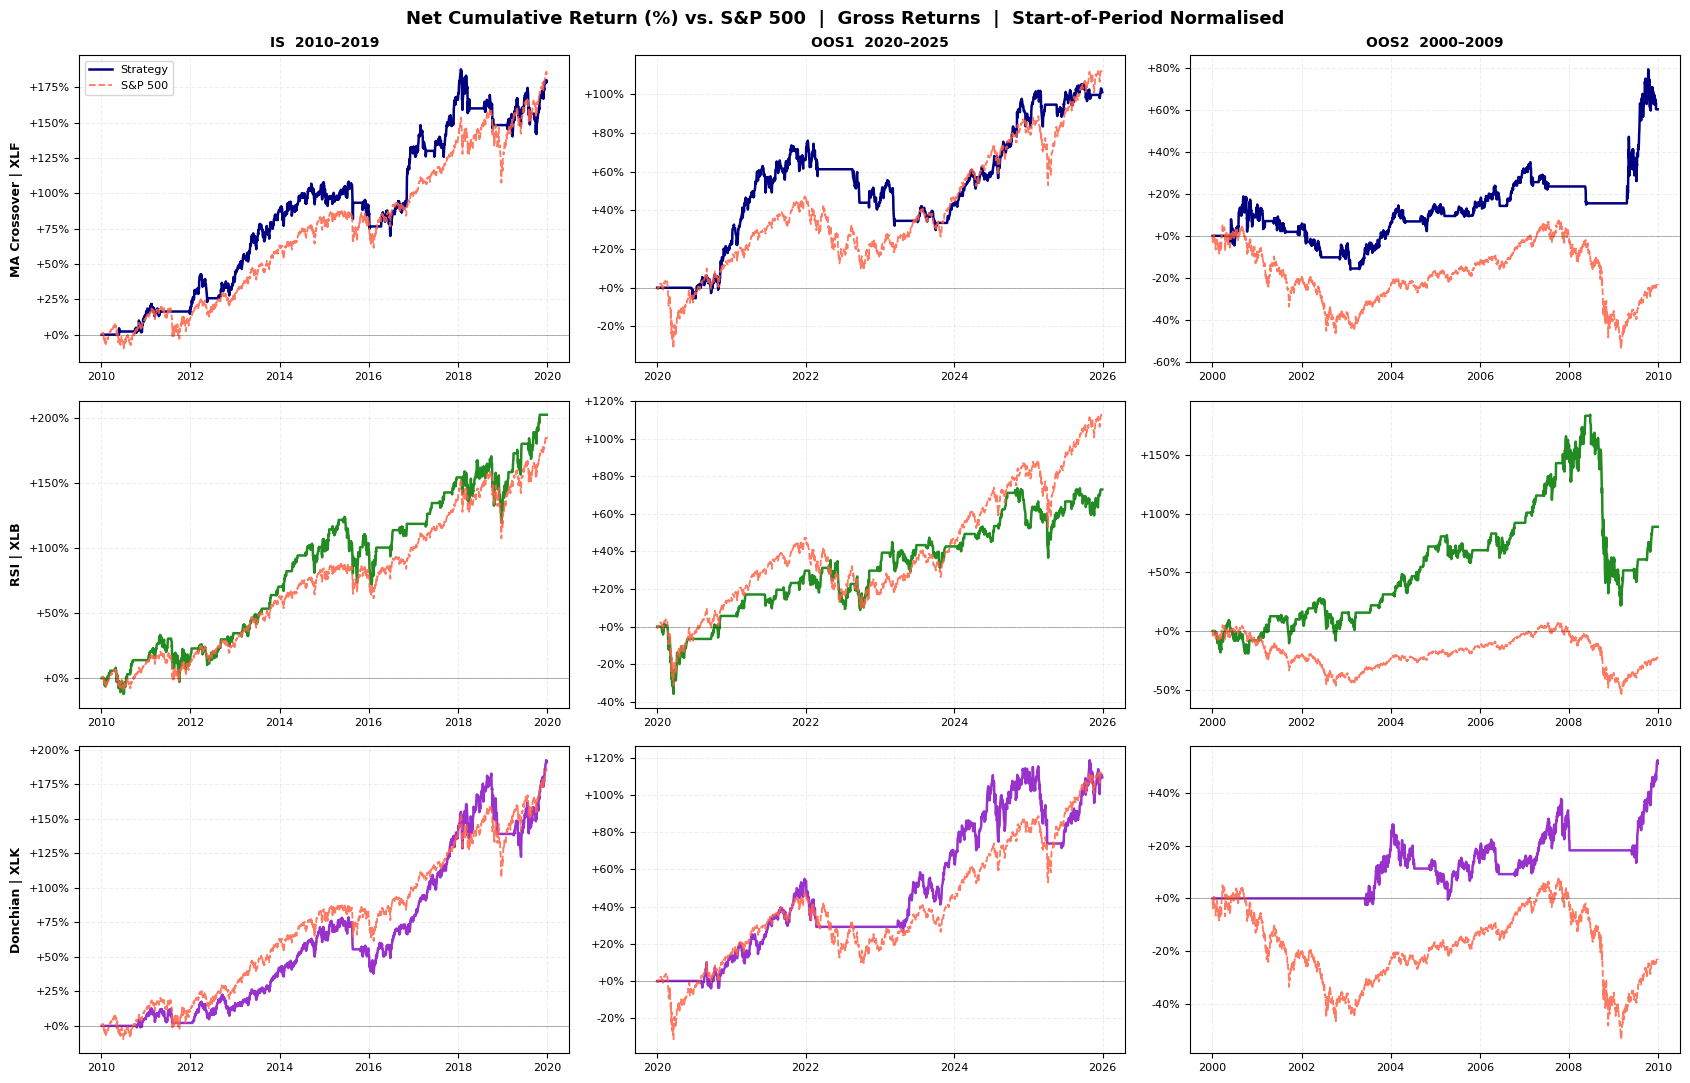

In [67]:
signal_rows = [
    ('MA Crossover | XLF',  pv_ma_is,  pv_ma_oos1,  pv_ma_oos2,
     df_finance_is,    df_finance_oos1,    df_finance_oos2,    'navy'),
    ('RSI | XLB',           pv_rsi_is, pv_rsi_oos1, pv_rsi_oos2,
     df_materials_is,  df_materials_oos1,  df_materials_oos2,  'forestgreen'),
    ('Donchian | XLK',      pv_don_is, pv_don_oos1, pv_don_oos2,
     df_technology_is, df_technology_oos1, df_technology_oos2, 'darkorchid'),
]
period_titles = ['IS  2010\u20132019', 'OOS1  2020\u20132025', 'OOS2  2000\u20132009']

fig, axes = plt.subplots(3, 3, figsize=(17, 11))
fig.suptitle(
    'Net Cumulative Return (%) vs. S&P 500  |  Gross Returns  |  Start-of-Period Normalised',
    fontsize=13, fontweight='bold'
)

for r, (sig_label, pv_is_, pv_oos1_, pv_oos2_,
        df_is_, df_oos1_, df_oos2_, color) in enumerate(signal_rows):

    for c, (pv_, df_, period_label) in enumerate([
        (pv_is_,   df_is_,   period_titles[0]),
        (pv_oos1_, df_oos1_, period_titles[1]),
        (pv_oos2_, df_oos2_, period_titles[2]),
    ]):
        ax = axes[r][c]
        dates = df_.index.to_numpy()
        spx_ref = spx_is if c == 0 else (spx_oos1 if c == 1 else spx_oos2)
        spx_v = _spx_slice(df_, spx_ref)

        net_strat = (pv_ / pv_[0] - 1) * 100
        net_spx   = (spx_v / spx_v[0] - 1) * 100

        ax.plot(dates, net_strat, color=color, lw=1.8, label='Strategy')
        ax.plot(dates, net_spx,   color='tomato', lw=1.3,
                linestyle='--', alpha=0.85, label='S&P 500')
        ax.axhline(0, color='black', lw=0.5, alpha=0.4)

        if r == 0:
            ax.set_title(period_label, fontsize=10, fontweight='bold')
        if c == 0:
            ax.set_ylabel(sig_label, fontsize=9, fontweight='bold')

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(True, which='both', alpha=0.2, linestyle='--')
        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()


### Drawdown Profiles — IS / OOS1 / OOS2

Shaded area shows the strategy underwater period; dashed red is the S&P 500 drawdown.

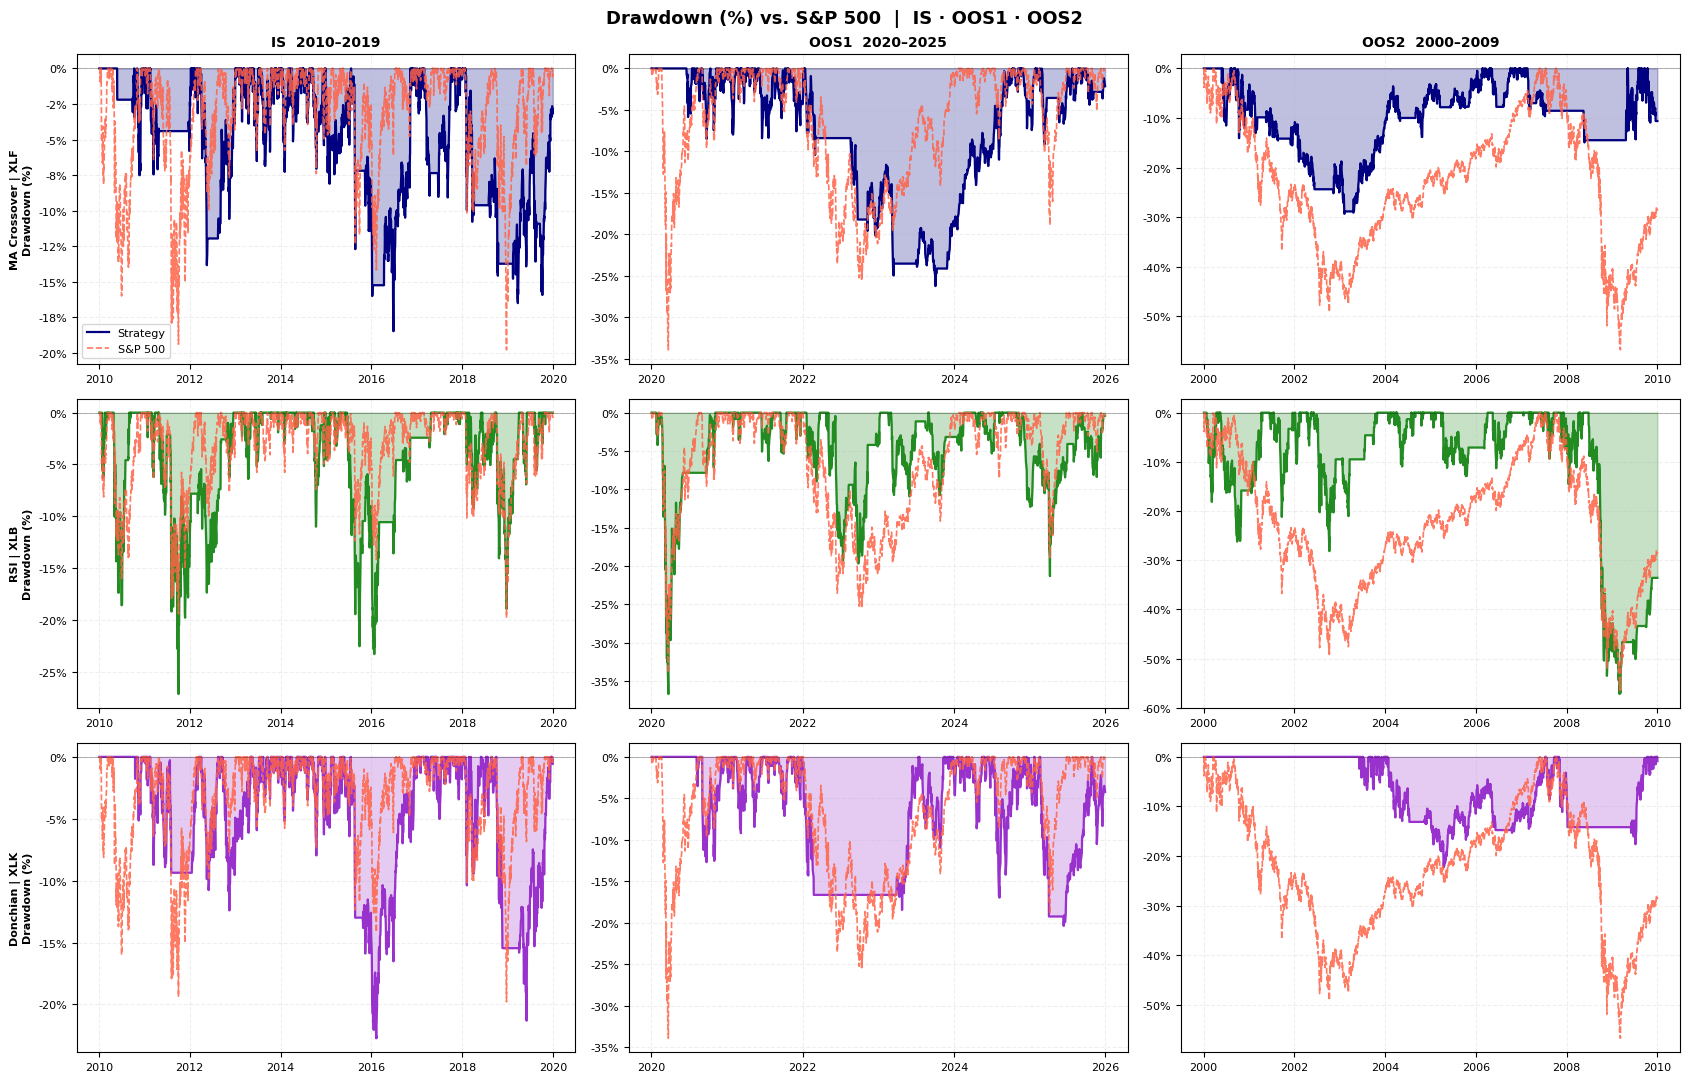

In [68]:
def compute_dd(pv):
    return (pv / np.maximum.accumulate(pv) - 1) * 100

fig_dd, axes_dd = plt.subplots(3, 3, figsize=(17, 11))
fig_dd.suptitle(
    'Drawdown (%) vs. S&P 500  |  IS \u00b7 OOS1 \u00b7 OOS2',
    fontsize=13, fontweight='bold'
)

for r, (sig_label, pv_is_, pv_oos1_, pv_oos2_,
        df_is_, df_oos1_, df_oos2_, color) in enumerate(signal_rows):

    for c, (pv_, df_, period_label) in enumerate([
        (pv_is_,   df_is_,   'IS  2010\u20132019'),
        (pv_oos1_, df_oos1_, 'OOS1  2020\u20132025'),
        (pv_oos2_, df_oos2_, 'OOS2  2000\u20132009'),
    ]):
        ax = axes_dd[r][c]
        dates = df_.index.to_numpy()
        spx_ref = spx_is if c == 0 else (spx_oos1 if c == 1 else spx_oos2)
        spx_v = _spx_slice(df_, spx_ref)

        dd_strat = compute_dd(pv_)
        dd_spx   = compute_dd(spx_v)

        ax.fill_between(dates, dd_strat, 0, alpha=0.25, color=color)
        ax.plot(dates, dd_strat, color=color, lw=1.6, label='Strategy')
        ax.plot(dates, dd_spx,   color='tomato', lw=1.2,
                linestyle='--', alpha=0.85, label='S&P 500')
        ax.axhline(0, color='black', lw=0.5, alpha=0.4)

        if r == 0:
            ax.set_title(period_label, fontsize=10, fontweight='bold')
        if c == 0:
            ax.set_ylabel(sig_label + '\nDrawdown (%)', fontsize=8, fontweight='bold')

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(True, which='both', alpha=0.2, linestyle='--')
        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()


---
## §9 — Conclusion

**Signal selection (§3)** confirmed that MA Crossover, RSI, and Donchian represent structurally distinct mechanisms — trend-following, oscillator mean reversion, and price-channel breakout respectively. We dropped Bollinger Bands after verifying its entry trigger is algebraically identical to the Z-Score formulation. MACD, Stochastic, and Z-Score remain in the catalogue as unexplored alternatives.

**Sector assignment (§4)** matched each signal to the sector whose return dynamics best fit its mechanism: financial rate cycles for MA Crossover (XLF), commodity price cycles for RSI (XLB), and technology adoption S-curves for Donchian (XLK). Single-ETF baskets eliminate single-name selection bias and provide near-full sector diversification.

**Sector screening (§4.1)** provided a data-driven sanity check using IS Basket Sortino as the primary ranking criterion. The screening rankings are consistent with our sector assignments; OOS2 results are reported as a pre-sample stress test.

**IS parameter optimisation (§5)** used exhaustive Sortino-ratio grid search on 2010–2019 data. Parameters are frozen here and applied without modification to all OOS windows:

$$\text{Sortino} = \frac{\bar{r}}{\text{DD}} \cdot \sqrt{252}$$

**Sensitivity analysis (§5.3)** confirmed smooth performance plateaux around the IS-optimal parameters — no knife-edge optimum was observed for any signal.

**OOS validation (§6)** applied frozen IS parameters to both held-out windows (OOS1: 2020–2025; OOS2: 2000–2009). All performance figures are **gross returns only** — no transaction costs are modelled.

**References:**
- Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley Trading.
- Sharpe, W. F. (1994). *The Sharpe Ratio.* JPM, 21(1), 49–58.
- Wilder, J. W. (1978). *New Concepts in Technical Trading Systems.* Trend Research.
- Sortino, F. A., & van der Meer, R. (1991). *Downside Risk.* JPM, 17(4), 27–31.
- Donchian, R. D. (1960). *High Finance in Copper.* Financial Analysts Journal.
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3).
- Shleifer, A., & Vishny, R. W. (1997). *The Limits of Arbitrage.* JF, 52(1), 35–55.
- McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1).
- Bailey, D. H., & López de Prado, M. (2014). *The Deflated Sharpe Ratio.* JPM, 40(5).
- Elton, E. J., & Gruber, M. J. (1997). *Modern Portfolio Theory and Investment Analysis.* Wiley.
- Korajczyk, R. A., & Sadka, R. (2004). *Are Momentum Profits Robust to Trading Costs?* JF, 59(3).